# Laboratorio 5 - Análisis de paquetes y detección de anomalías
## Security Data Science
### Edwin Andrés Ortega Kou - 22305

### Scapy 

In [2]:
from scapy.all import * 
import pandas as pd 
import numpy as np
import binascii 
import seaborn as sns
sns.set(color_codes=True)
%matplotlib inline

## Análisis de paquetes

### Carga del archivo PCAP

In [3]:
pcap = rdpcap("data/analisis_paquetes.pcap")

print("Cantidad de paquetes:", len(pcap))
print("Tipo de objeto:", type(pcap))

Cantidad de paquetes: 62
Tipo de objeto: <class 'scapy.plist.PacketList'>


### Inspección inicial del archivo

In [4]:
# Ver el primer paquete:
pcap[0]

<Ether  dst=80:37:73:96:9b:db src=88:e9:fe:6a:92:52 type=IPv4 |<IP  version=4 ihl=5 tos=0x0 len=961 id=1 flags= frag=0 ttl=64 proto=udp chksum=0x52e6 src=10.1.10.53 dst=84.54.22.33 |<UDP  sport=domain dport=domain len=941 chksum=0xf60e |<DNS  id=12 qr=0 opcode=QUERY aa=0 tc=0 rd=1 ra=0 z=0 ad=0 cd=0 rcode=ok qdcount=1 ancount=0 nscount=0 arcount=0 qd=[<DNSQR  qname=b'google.com.' qtype=AAAA unicastresponse=0 qclass=IN |>] |<Raw  load=b'\xef\xbf\xbdPNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01b\x00\x00\x00\xef\xbf\xbd\x08\x06\x00\x00\x00(\xef\xbf\xbdTR\x00\x00:\xef\xbf\xbdIDATx\xef\xbf\xbd\xef\xbf\xbd\t|T\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd;K\x12\x08;\x08\xef\xbf\xbd\nE\xef\xbf\xbd\xef\xbf\xbd$\x19\xef\xbf\xbd\xef\xbf\xbdZi\xdf\xaa-\xef\xbf\xbd;N2\xef\xbf\xbd\xef\xbf\xbdV\xef\xbf\xbdV\xef\xbf\xbda\xef\xbf\xbdZ\x11!\xef\xbf\xbd\xef\xbf\xbd\x01\xdc\xbbik[\xef\xbf\xbd.ok\xef\xbf\xbde\xef\xbf\xbd\x01\\\xef\xbf\xbd\xef\xbf\xbd]\xef\xbf\xbd-\xef\xbf\xbd\xef\xbf\xbd\xef\x

In [5]:
# Resumen corto del primer paquete
pcap[0].summary()

"Ether / IP / UDP / DNS Qry b'google.com.' / Raw"

### Análisis del primer paquete

In [6]:
ethernet_frame = pcap[0]
ip_packet = ethernet_frame.payload
segment = ip_packet.payload
data = segment.payload

print("Capa de enlace:", type(ethernet_frame))
print("Capa de red:", type(ip_packet))
print("Capa de transporte:", type(segment))
print("Payload:", type(data))

Capa de enlace: <class 'scapy.layers.l2.Ether'>
Capa de red: <class 'scapy.layers.inet.IP'>
Capa de transporte: <class 'scapy.layers.inet.UDP'>
Payload: <class 'scapy.layers.dns.DNS'>


### Visualización en hexadecimal

In [7]:
hexdump(pcap[0])

0000  80 37 73 96 9B DB 88 E9 FE 6A 92 52 08 00 45 00  .7s......j.R..E.
0010  03 C1 00 01 00 00 40 11 52 E6 0A 01 0A 35 54 36  ......@.R....5T6
0020  16 21 00 35 00 35 03 AD F6 0E 00 0C 01 00 00 01  .!.5.5..........
0030  00 00 00 00 00 00 06 67 6F 6F 67 6C 65 03 63 6F  .......google.co
0040  6D 00 00 1C 00 01 EF BF BD 50 4E 47 0D 0A 1A 0A  m........PNG....
0050  00 00 00 0D 49 48 44 52 00 00 01 62 00 00 00 EF  ....IHDR...b....
0060  BF BD 08 06 00 00 00 28 EF BF BD 54 52 00 00 3A  .......(...TR..:
0070  EF BF BD 49 44 41 54 78 EF BF BD EF BF BD 09 7C  ...IDATx.......|
0080  54 EF BF BD EF BF BD EF BF BD EF BF BD EF BF BD  T...............
0090  3B 4B 12 08 3B 08 EF BF BD 0A 45 EF BF BD EF BF  ;K..;.....E.....
00a0  BD 24 19 EF BF BD EF BF BD 5A 69 DF AA 2D EF BF  .$.......Zi..-..
00b0  BD 3B 4E 32 EF BF BD EF BF BD 56 EF BF BD 56 EF  .;N2......V...V.
00c0  BF BD 61 EF BF BD 5A 11 21 EF BF BD EF BF BD 01  ..a...Z.!.......
00d0  DC BB 69 6B 5B EF BF BD 2E 6F 6B EF BF BD 65 EF  ..ik[....

### Campos disponibles en el paquete

In [8]:
ls(pcap[0])

dst        : DestMACField                        = '80:37:73:96:9b:db' ('None')
src        : SourceMACField                      = '88:e9:fe:6a:92:52' ('None')
type       : XShortEnumField                     = 2048            ('36864')
--
version    : BitField  (4 bits)                  = 4               ('4')
ihl        : BitField  (4 bits)                  = 5               ('None')
tos        : XByteField                          = 0               ('0')
len        : ShortField                          = 961             ('None')
id         : ShortField                          = 1               ('1')
flags      : FlagsField                          = <Flag 0 ()>     ('<Flag 0 ()>')
frag       : BitField  (13 bits)                 = 0               ('0')
ttl        : ByteField                           = 64              ('64')
proto      : ByteEnumField                       = 17              ('0')
chksum     : XShortField                         = 21222           ('None')
src       

### Resumen del paquete analizado

In [9]:
print(pcap[0].summary())

Ether / IP / UDP / DNS Qry b'google.com.' / Raw


## Testeo de la herramienta

### Capturas los 10 paquetes

In [10]:
pcap_test = sniff(count=10)

print("Tipo de dato:", type(pcap_test))
print("Cantidad de paquetes capturados:", len(pcap_test))

Tipo de dato: <class 'scapy.plist.PacketList'>
Cantidad de paquetes capturados: 10


### Muestras del contenido general

In [11]:
pcap_test.summary()

Ether / IP / TCP 192.168.58.106:61317 > 13.89.179.9:https FA
Ether / IP / TCP 13.89.179.9:https > 192.168.58.106:61317 FA
Ether / IP / TCP 192.168.58.106:61317 > 13.89.179.9:https A
Ether / IP / UDP 192.168.58.1:5246 > 192.168.58.255:5246 / Raw
Ether / IP / TCP 192.168.58.106:58110 > 18.64.155.49:https A / Raw
Ether / IP / TCP 18.64.155.49:https > 192.168.58.106:58110 A
Ether / IP / UDP 192.168.58.1:2313 > 192.168.58.255:2313 / Raw
Ether / IP / UDP 192.168.58.1:3517 > 224.0.1.178:3517 / Raw
Ether / IP / UDP / DNS Qry b'mobile.events.data.microsoft.com.'
Ether / fe80::38a5:7dff:fead:62db > ff02::16 (0) / IPv6ExtHdrHopByHop / ICMPv6MLReport2


### Interpretación

In [12]:
data_test = []

for pkt in pcap_test:
    if IP in pkt:
        src_port = None
        dst_port = None
        
        if TCP in pkt:
            src_port = pkt[TCP].sport
            dst_port = pkt[TCP].dport
        elif UDP in pkt:
            src_port = pkt[UDP].sport
            dst_port = pkt[UDP].dport

        data_test.append({
            "Src Address": pkt[IP].src,
            "Dst Address": pkt[IP].dst,
            "Src Port": src_port,
            "Dst Port": dst_port
        })

df_test = pd.DataFrame(data_test)
df_test

,Src Address,Dst Address,Src Port,Dst Port
0,192.168.58.106,13.89.179.9,61317,443
1,13.89.179.9,192.168.58.106,443,61317
2,192.168.58.106,13.89.179.9,61317,443
3,192.168.58.1,192.168.58.255,5246,5246
4,192.168.58.106,18.64.155.49,58110,443
5,18.64.155.49,192.168.58.106,443,58110
6,192.168.58.1,192.168.58.255,2313,2313
7,192.168.58.1,224.0.1.178,3517,3517
8,192.168.58.106,9.9.9.9,65237,53


### Observación

La tabla anterior resume información básica de conectividad entre hosts. Las direcciones IP permiten identificar el origen y destino de la comunicación, mientras que los puertos ayudan a inferir qué servicios o aplicaciones están participando en el tráfico capturado.

### Validación de la captura en tráfico real

In [13]:
df_test.describe(include='all')

,Src Address,Dst Address,Src Port,Dst Port
count,9,9,9.000000,9.000000
unique,4,6,NaN,NaN
top,192.168.58.106,13.89.179.9,NaN,NaN
freq,4,2,NaN,NaN
mean,NaN,NaN,28660.333333,14653.888889
std,NaN,NaN,31235.170798,25616.766440
min,NaN,NaN,443.000000,53.000000
25%,NaN,NaN,2313.000000,443.000000
50%,NaN,NaN,5246.000000,2313.000000
75%,NaN,NaN,61317.000000,5246.000000


In [14]:
df_test["Dst Port"].value_counts()

Dst Port
443      3
61317    1
5246     1
58110    1
2313     1
3517     1
53       1
Name: count, dtype: int64

## Estadísticas y detección con Z-Score

### Convertir PCAP a un DataFrame

In [15]:
data = []

for pkt in pcap:
    if IP in pkt:
        src_port = None
        dst_port = None
        payload_len = 0

        if TCP in pkt:
            src_port = pkt[TCP].sport
            dst_port = pkt[TCP].dport
            payload_len = len(pkt[TCP].payload)

        elif UDP in pkt:
            src_port = pkt[UDP].sport
            dst_port = pkt[UDP].dport
            payload_len = len(pkt[UDP].payload)

        data.append({
            "src": pkt[IP].src,
            "dst": pkt[IP].dst,
            "sport": src_port,
            "dport": dst_port,
            "payload_len": payload_len
        })

df = pd.DataFrame(data)

df.head()

,src,dst,sport,dport,payload_len
0,10.1.10.53,84.54.22.33,53,53,933
1,84.54.22.33,10.1.10.53,53,53,56
2,10.1.10.53,84.54.22.33,53,53,947
3,84.54.22.33,10.1.10.53,53,53,56
4,10.1.10.53,84.54.22.33,53,53,984


In [16]:
type(df)

pandas.core.frame.DataFrame

In [17]:
df.columns

Index(['src', 'dst', 'sport', 'dport', 'payload_len'], dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   src          62 non-null     object
 1   dst          62 non-null     object
 2   sport        62 non-null     int64 
 3   dport        62 non-null     int64 
 4   payload_len  62 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 2.6+ KB


### Estadísticas básicas

#### a. IP origen más frecuente

In [19]:
most_src = df["src"].value_counts().idxmax()
print("IP origen más frecuente:", most_src)

IP origen más frecuente: 10.1.10.53


La IP de origen más frecuente corresponde a una dirección interna de la red. Esto indica que este host es el que más tráfico genera dentro del archivo capturado, consistente con un cliente que realiza múltiples solicitudes en la red.

#### b. IP destino más frecuente

In [20]:
most_dst = df["dst"].value_counts().idxmax()
print("IP destino más frecuente:", most_dst)

IP destino más frecuente: 10.1.10.53


La IP destino más frecuente es una dirección externa. Eso dice que el tráfico está dirigido principalmente hacia un servidor específico, lo cual es típico en comunicaciones como consultas DNS o acceso a servicios externos.

#### c. ¿A qué IPs se comunica la IP del inciso a?

In [21]:
df[df["src"] == most_src]["dst"].unique()

array(['84.54.22.33', '75.75.75.75'], dtype=object)

La IP origen más frecuente se comunica principalmente con una o pocas direcciones IP externas. En este caso, se observa que la comunicación se da principalmente con un servidor específico, lo cual refuerza la idea de que se trata de tráfico dirigido, como consultas DNS hacia un servidor resolutor.

#### d. ¿A qué puertos destino se comunica la IP del inciso a?

In [22]:
df[df["src"] == most_src]["dport"].value_counts()

dport
53    31
Name: count, dtype: int64

La IP origen más frecuente se comunica principalmente al puerto 53, lo cual indica tráfico DNS. Este puerto es utilizado para la resolución de nombres de dominio, lo que sugiere que el host está realizando consultas DNS.

#### e. ¿A qué puertos origen se comunica la IP del inciso b?

In [23]:
df[df["dst"] == most_dst]["sport"].value_counts()

sport
53    31
Name: count, dtype: int64

La IP destino más frecuente también utiliza el puerto 53 como puerto origen en las respuestas. Esto es consistente con el comportamiento de un servidor DNS, que responde desde el mismo puerto al que recibió la solicitud.

#### f. Propósito de los puertos

Análisis de puertos

Los puertos más frecuentes observados corresponden a servicios conocidos:

- 80: HTTP
- 443: HTTPS
- 53: DNS

Esto indica que el tráfico capturado corresponde principalmente a navegación web y resolución de nombres de dominio.

### Z-Score sobre el tamaño de payload

#### a. Calcular Z-score

In [24]:
mean_payload = df["payload_len"].mean()
std_payload = df["payload_len"].std()

df["z_score"] = (df["payload_len"] - mean_payload) / std_payload

df[np.abs(df["z_score"]) > 2]

,src,dst,sport,dport,payload_len,z_score


Al aplicar el Z-score utilizando la media y desviación estándar del dataset, no se detectaron paquetes con |Z| > 2. Esto indica que, desde una perspectiva puramente estadística, no hay valores extremos.

Sin embargo, esto puede deberse a que la distribución de los datos no es normal y presenta valores altos de forma frecuente, lo cual incrementa la media y la desviación estándar. Como resultado, el método pierde sensibilidad para detectar anomalías reales.

#### b. Histograma

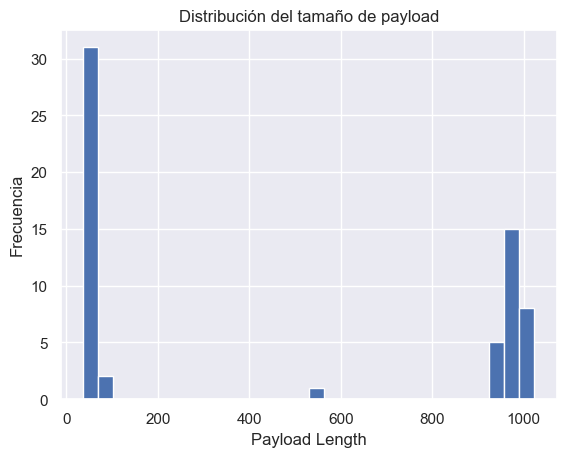

In [25]:
import matplotlib.pyplot as plt

plt.hist(df["payload_len"], bins=30)
plt.title("Distribución del tamaño de payload")
plt.xlabel("Payload Length")
plt.ylabel("Frecuencia")
plt.show()

Se observa que la distribución no es normal. En particular, hay una mezcla de paquetes pequeños y paquetes mucho más grandes. Debido a esta distribución, la media y la desviación estándar aumentan, lo que hace que los valores grandes no sean considerados anomalías por el Z-score. Esto explica por qué el método no detectó valores anómalos en el inciso anterior.

#### c. Z-score con DNS

In [26]:
mean_dns = 50
std_dns = 15

df["z_score_dns"] = (df["payload_len"] - mean_dns) / std_dns

df[np.abs(df["z_score_dns"]) > 2]

,src,dst,sport,dport,payload_len,z_score,z_score_dns
0,10.1.10.53,84.54.22.33,53,53,933,0.981296,58.866667
2,10.1.10.53,84.54.22.33,53,53,947,1.011713,59.800000
4,10.1.10.53,84.54.22.33,53,53,984,1.092101,62.266667
6,10.1.10.53,84.54.22.33,53,53,970,1.061684,61.333333
8,10.1.10.53,84.54.22.33,53,53,975,1.072547,61.666667
10,10.1.10.53,84.54.22.33,53,53,1017,1.163798,64.466667
12,10.1.10.53,84.54.22.33,53,53,980,1.083410,62.000000
14,10.1.10.53,84.54.22.33,53,53,951,1.020404,60.066667
16,10.1.10.53,84.54.22.33,53,53,931,0.976951,58.733333
18,10.1.10.53,84.54.22.33,53,53,964,1.048648,60.933333


Al aplicar el Z-score utilizando valores típicos de tráfico DNS, se detectan múltiples paquetes con valores de |Z| > 2. En particular, los paquetes con tamaños cercanos a 900–1000 bytes son claramente identificados como anomalías. Esto indica que, aunque el dataset no mostraba anomalías desde una perspectiva global, sí existen comportamientos inusuales cuando se analiza con conocimiento del protocolo.

#### d. ¿Qué puede decir que nos enseña esto sobre la importancia de conocer el o los protocolos a analizar al aplicar técnicas de detección de anomalías?

Este ejercicio demuestra que el uso de técnicas estadísticas como el Z-score depende fuertemente del conocimiento del dominio. Si solo se utilizan estadísticas del dataset, es posible que las anomalías no sean detectadas debido a la forma de la distribución de los datos. En cambio, al incorporar conocimiento sobre el comportamiento esperado de un protocolo (como el tamaño típico de paquetes DNS), es posible identificar anomalías de manera más efectiva. Esto resalta la importancia de combinar análisis estadístico con conocimiento del contexto en el análisis de tráfico de red.

## Gráficas de payload

### a. IP origen vs suma de payload

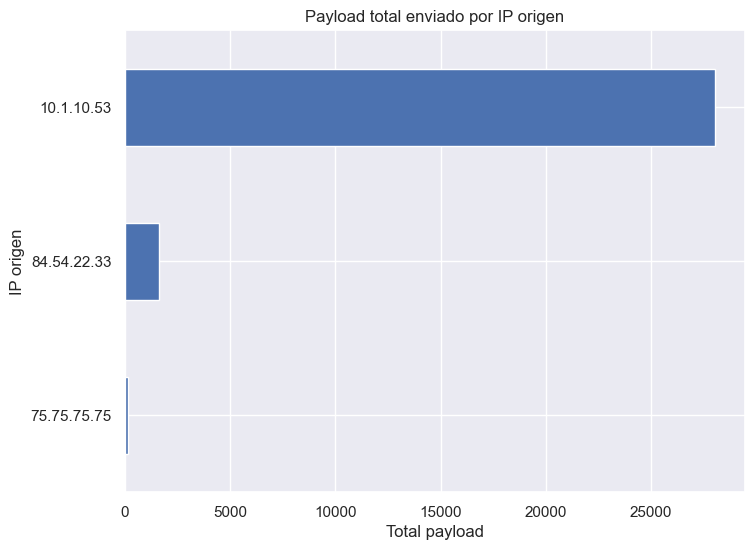

In [27]:
payload_by_src = df.groupby("src")["payload_len"].sum().sort_values()

plt.figure(figsize=(8,6))
payload_by_src.plot(kind="barh")
plt.title("Payload total enviado por IP origen")
plt.xlabel("Total payload")
plt.ylabel("IP origen")
plt.show()

#### Análisis de la gráfica (IP origen vs payload)

En la gráfica se observa que la dirección IP 10.1.10.53 es la que envía la mayor cantidad de payload dentro del tráfico analizado. Esto indica que esta IP es la principal generadora de solicitudes en la red, lo cual es consistente con el comportamiento de un cliente.

Por otro lado, la IP 84.54.22.33 también envía cierta cantidad de datos, pero en menor proporción, lo cual sugiere que corresponde a un servidor que responde a las solicitudes. Finalmente, la IP 75.75.75.75 presenta un volumen muy bajo de tráfico, por lo que su participación en la comunicación es mínima.

### b. IP destino vs suma de payload

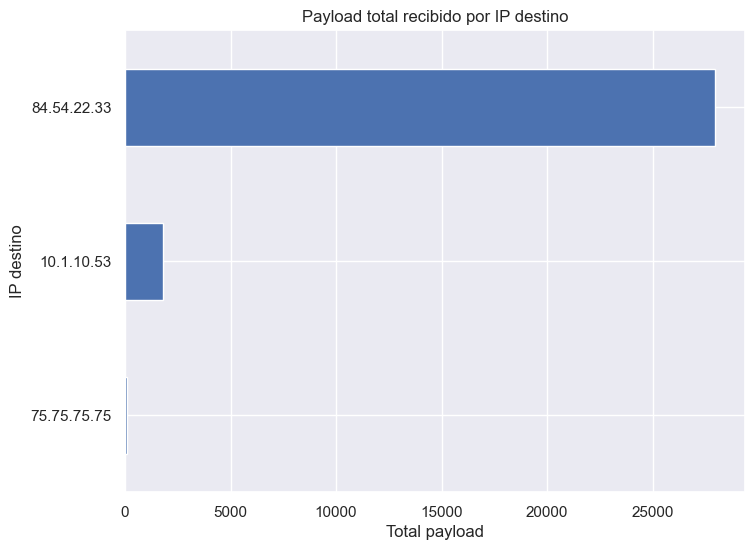

In [28]:
payload_by_dst = df.groupby("dst")["payload_len"].sum().sort_values()

plt.figure(figsize=(8,6))
payload_by_dst.plot(kind="barh")
plt.title("Payload total recibido por IP destino")
plt.xlabel("Total payload")
plt.ylabel("IP destino")
plt.show()

#### Análisis de la gráfica (IP destino vs payload)

En esta gráfica se observa que la IP 84.54.22.33 recibe la mayor cantidad de payload, lo que indica que actúa como el principal destino de las solicitudes generadas en la red.

La IP 10.1.10.53 también recibe datos, pero en menor cantidad, lo cual es consistente con el comportamiento de un cliente que recibe respuestas del servidor. La IP 75.75.75.75 nuevamente presenta una participación mínima, lo que sugiere que no es un actor relevante dentro del tráfico analizado.

### c. Puertos origen vs suma de payload

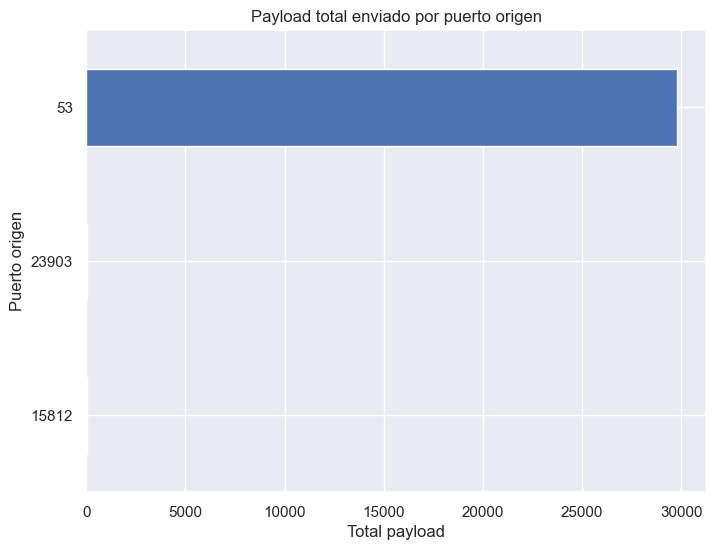

In [29]:
payload_by_sport = df.groupby("sport")["payload_len"].sum().sort_values()

plt.figure(figsize=(8,6))
payload_by_sport.plot(kind="barh")
plt.title("Payload total enviado por puerto origen")
plt.xlabel("Total payload")
plt.ylabel("Puerto origen")
plt.show()

#### Análisis de la gráfica (puerto origen vs payload)

La gráfica muestra claramente que el puerto 53 concentra prácticamente todo el payload enviado. Esto indica que la mayoría del tráfico corresponde a comunicaciones DNS.

Los otros puertos observados presentan valores muy bajos, lo que sugiere que su participación en el tráfico es mínima. En conjunto, esto confirma que el tráfico analizado está dominado por consultas y respuestas DNS.

### d. Puertos destino vs suma de payload

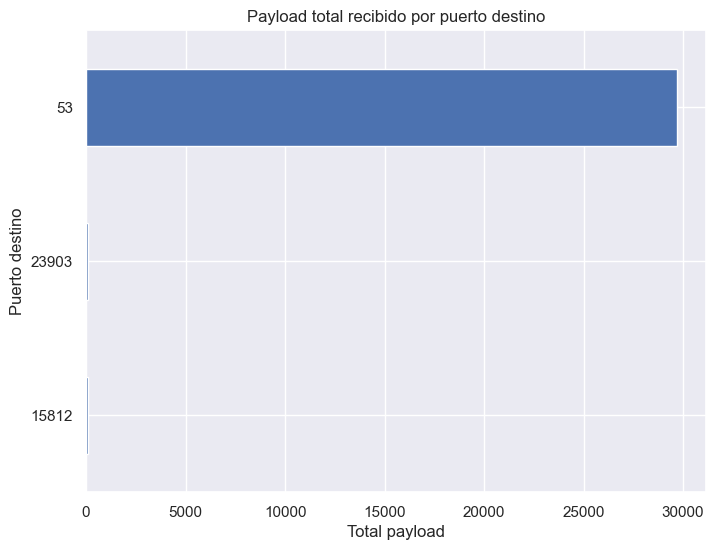

In [30]:
payload_by_dport = df.groupby("dport")["payload_len"].sum().sort_values()

plt.figure(figsize=(8,6))
payload_by_dport.plot(kind="barh")
plt.title("Payload total recibido por puerto destino")
plt.xlabel("Total payload")
plt.ylabel("Puerto destino")
plt.show()

#### Análisis de la gráfica (puerto destino vs payload)

En esta gráfica se observa que el puerto 53 también domina el payload recibido, lo cual refuerza la conclusión de que el tráfico corresponde principalmente a comunicaciones DNS.

Los demás puertos tienen una contribución muy baja en comparación, lo que indica que no hay una diversidad significativa de servicios en el tráfico analizado. Esto sugiere que la actividad de red está altamente concentrada en un solo tipo de protocolo.

### Conclusión general de las gráficas

Las gráficas confirman que el tráfico de red está dominado por comunicaciones entre una IP interna (10.1.10.53) y una IP externa (84.54.22.33) a través del puerto 53, lo que indica tráfico DNS.

Además, el volumen de payload observado en algunos paquetes es considerablemente alto para este tipo de protocolo, lo cual coincide con el análisis previo de anomalías. Esto refuerza la importancia de complementar el análisis visual con técnicas estadísticas y conocimiento del dominio.

## Detección automática con Isolation Forest

In [31]:
df["pkt_len"] = df["payload_len"]

### Calcular contamination

Calcula cuántas anomalías se encuentran con DNS

In [32]:
anomalies_dns = df[np.abs(df["z_score_dns"]) > 2]
contamination = len(anomalies_dns) / len(df)

print("Contamination:", contamination)

Contamination: 0.4838709677419355


### Entrenar Isolation Forest

In [33]:
from sklearn.ensemble import IsolationForest

features = df[["payload_len", "pkt_len"]]

model = IsolationForest(contamination=contamination, random_state=42)
df["anomaly_if"] = model.fit_predict(features)

### Revisión de Anomalías

In [34]:
anomalies_if = df[df["anomaly_if"] == -1]
anomalies_if

,src,dst,sport,dport,payload_len,z_score,z_score_dns,pkt_len,anomaly_if
0,10.1.10.53,84.54.22.33,53,53,933,0.981296,58.866667,933,-1
2,10.1.10.53,84.54.22.33,53,53,947,1.011713,59.800000,947,-1
4,10.1.10.53,84.54.22.33,53,53,984,1.092101,62.266667,984,-1
6,10.1.10.53,84.54.22.33,53,53,970,1.061684,61.333333,970,-1
8,10.1.10.53,84.54.22.33,53,53,975,1.072547,61.666667,975,-1
10,10.1.10.53,84.54.22.33,53,53,1017,1.163798,64.466667,1017,-1
12,10.1.10.53,84.54.22.33,53,53,980,1.083410,62.000000,980,-1
14,10.1.10.53,84.54.22.33,53,53,951,1.020404,60.066667,951,-1
16,10.1.10.53,84.54.22.33,53,53,931,0.976951,58.733333,931,-1
18,10.1.10.53,84.54.22.33,53,53,964,1.048648,60.933333,964,-1


In [36]:
print("Número de anomalías:", len(anomalies_if))

Número de anomalías: 30


### a. Paquetes detectados como anomalías

El modelo Isolation Forest identificó 30 anomalías, donde mayoria de estos paquetes que presentan valores atípicos en las variables utilizadas, principalmente el tamaño del payload.

En particular, la mayoría de las anomalías corresponden a paquetes con tamaños de payload elevados (aproximadamente entre 900 y 1000 bytes), asociados principalmente a la comunicación entre las direcciones IP 10.1.10.53 y 84.54.22.33 a través del puerto 53.

Adicionalmente, también se detectaron algunos paquetes con tamaños de payload pequeños, lo cual se debe al alto valor del parámetro contamination, que obliga al modelo a clasificar una proporción considerable de los datos como anomalías.

### b. Comparación con Z-score

Las anomalías detectadas por el modelo Isolation Forest coinciden en gran medida con los patrones sospechosos identificados previamente mediante el Z-score basado en conocimiento de dominio.

En ambos casos, los paquetes con tamaños de payload elevados, que no son típicos para el tráfico DNS, son considerados como anomalías. Esto confirma que existe un comportamiento inusual en el dataset, especialmente en las comunicaciones entre las IPs 10.1.10.53 y 84.54.22.33.

Sin embargo, el modelo Isolation Forest también detecta un mayor número de anomalías en comparación con el Z-score. Esto se debe al valor elevado del parámetro contamination, el cual obliga al modelo a marcar una mayor proporción de los datos como anómalos.

En general, se puede concluir que ambos métodos coinciden en identificar los paquetes más sospechosos, aunque el Isolation Forest es más flexible al no depender de supuestos estadísticos sobre la distribución de los datos.

## Investigación del payload

### a. Nuevo DataFrame con únicamente las conexiones de la IP origen más frecuente

In [37]:
most_src = df["src"].value_counts().idxmax()
print(f"IP origen más frecuente: {most_src}")

IP origen más frecuente: 10.1.10.53


In [38]:
df_most_src = df[df["src"] == most_src].copy()
df_most_src.head()

,src,dst,sport,dport,payload_len,z_score,z_score_dns,pkt_len,anomaly_if
0,10.1.10.53,84.54.22.33,53,53,933,0.981296,58.866667,933,-1
2,10.1.10.53,84.54.22.33,53,53,947,1.011713,59.800000,947,-1
4,10.1.10.53,84.54.22.33,53,53,984,1.092101,62.266667,984,-1
6,10.1.10.53,84.54.22.33,53,53,970,1.061684,61.333333,970,-1
8,10.1.10.53,84.54.22.33,53,53,975,1.072547,61.666667,975,-1


Se creó un nuevo DataFrame filtrando únicamente los paquetes cuya IP de origen corresponde a la dirección más frecuente, que en este caso es 10.1.10.53. Esto permite enfocar la investigación en el host que genera la mayor parte del tráfico y sobre el cual ya se habían detectado comportamientos sospechosos en los análisis previos.

### b. Nuevo DataFrame con Src Address, Dst Address y agrupación por payload

In [39]:
payload_rows = []

for pkt in pcap:
    if IP in pkt and pkt[IP].src == most_src:
        payload_bytes = b""
        
        if TCP in pkt:
            payload_bytes = bytes(pkt[TCP].payload)
        elif UDP in pkt:
            payload_bytes = bytes(pkt[UDP].payload)

        payload_rows.append({
            "Src Address": pkt[IP].src,
            "Dst Address": pkt[IP].dst,
            "payload": payload_bytes,
            "payload_len": len(payload_bytes)
        })

df_payload = pd.DataFrame(payload_rows)
df_payload.head()

,Src Address,Dst Address,payload,payload_len
0,10.1.10.53,84.54.22.33,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,933
1,10.1.10.53,84.54.22.33,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,947
2,10.1.10.53,84.54.22.33,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,984
3,10.1.10.53,84.54.22.33,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,970
4,10.1.10.53,84.54.22.33,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,975


In [40]:
df_payload_grouped = (
    df_payload.groupby(["Src Address", "Dst Address", "payload"])
    .size()
    .reset_index(name="count")
)

df_payload_grouped.head()

,Src Address,Dst Address,payload,count
0,10.1.10.53,75.75.75.75,b'Q\x19\x01\x00\x00\x01\x00\x00\x00\x00\x00\x0...,1
1,10.1.10.53,75.75.75.75,b'\xda\xd1\x01\x00\x00\x01\x00\x00\x00\x00\x00...,1
2,10.1.10.53,84.54.22.33,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,1
3,10.1.10.53,84.54.22.33,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,1
4,10.1.10.53,84.54.22.33,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,1


Se construyó un nuevo DataFrame con las columnas Src Address, Dst Address y payload, y luego se agruparon los registros por payload. El objetivo de este paso fue identificar patrones repetidos en el contenido transmitido y separar mejor las conversaciones según la información real que viaja en los paquetes, no solo por IPs o puertos.

### c. Obtener la IP que más ha intercambiado bytes con la IP más frecuente

In [41]:
bytes_exchanged = (
    df[
        (df["src"] == most_src) | (df["dst"] == most_src)
    ]
    .assign(peer=lambda x: np.where(x["src"] == most_src, x["dst"], x["src"]))
    .groupby("peer")["payload_len"]
    .sum()
    .sort_values(ascending=False)
)

bytes_exchanged

peer
84.54.22.33    29603
75.75.75.75      240
Name: payload_len, dtype: int64

In [42]:
suspicious_ip = bytes_exchanged.idxmax()
print(f"La IP que más ha intercambiado bytes con {most_src} es: {suspicious_ip}")

La IP que más ha intercambiado bytes con 10.1.10.53 es: 84.54.22.33


La IP que más ha intercambiado bytes con la IP más frecuente corresponde a 84.54.22.33. Esto coincide con la IP sospechosa identificada anteriormente mediante las técnicas automáticas, ya que tanto en las estadísticas básicas, como en las gráficas, el Z-score y el Isolation Forest, esa dirección aparecía como la contraparte principal en la comunicación con 10.1.10.53. Esto confirma que el análisis automático estaba apuntando correctamente a la conversación más relevante.

### d. Crear un DataFrame con la conversación entre la IP más frecuente y la IP sospechosa

In [43]:
df_conversation = df[
    ((df["src"] == most_src) & (df["dst"] == suspicious_ip)) |
    ((df["src"] == suspicious_ip) & (df["dst"] == most_src))
].copy()

df_conversation.head()

,src,dst,sport,dport,payload_len,z_score,z_score_dns,pkt_len,anomaly_if
0,10.1.10.53,84.54.22.33,53,53,933,0.981296,58.866667,933,-1
1,84.54.22.33,10.1.10.53,53,53,56,-0.924107,0.400000,56,1
2,10.1.10.53,84.54.22.33,53,53,947,1.011713,59.800000,947,-1
3,84.54.22.33,10.1.10.53,53,53,56,-0.924107,0.400000,56,1
4,10.1.10.53,84.54.22.33,53,53,984,1.092101,62.266667,984,-1


Se creó un nuevo DataFrame que contiene únicamente la conversación entre 10.1.10.53 y 84.54.22.33. Este filtrado permitió aislar el tráfico sospechoso y revisar directamente la comunicación entre el posible cliente comprometido y el host externo con el que más intercambia información.

### e. Obtener los payloads del DataFrame anterior y añadir cada uno en un array

In [44]:
payload_array = []

for pkt in pcap:
    if IP in pkt:
        src_ip = pkt[IP].src
        dst_ip = pkt[IP].dst

        if ((src_ip == most_src and dst_ip == suspicious_ip) or
            (src_ip == suspicious_ip and dst_ip == most_src)):

            payload_bytes = b""

            if TCP in pkt:
                payload_bytes = bytes(pkt[TCP].payload)
            elif UDP in pkt:
                payload_bytes = bytes(pkt[UDP].payload)

            payload_array.append(payload_bytes)

print(f"Cantidad de payloads extraídos: {len(payload_array)}")

Cantidad de payloads extraídos: 58


A partir de esa conversación filtrada, se extrajeron los payloads y se almacenaron en un arreglo. Como resultado, se obtuvieron 58 payloads, que luego se utilizaron para la inspección manual del contenido. Este paso fue importante porque permitió revisar directamente qué datos estaban siendo transportados dentro de la comunicación sospechosa.

### f. Mostrar el contenido del primer array

In [45]:
first_payload = payload_array[0]
print(first_payload)

b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00\x00\x06google\x03com\x00\x00\x1c\x00\x01\xef\xbf\xbdPNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01b\x00\x00\x00\xef\xbf\xbd\x08\x06\x00\x00\x00(\xef\xbf\xbdTR\x00\x00:\xef\xbf\xbdIDATx\xef\xbf\xbd\xef\xbf\xbd\t|T\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd;K\x12\x08;\x08\xef\xbf\xbd\nE\xef\xbf\xbd\xef\xbf\xbd$\x19\xef\xbf\xbd\xef\xbf\xbdZi\xdf\xaa-\xef\xbf\xbd;N2\xef\xbf\xbd\xef\xbf\xbdV\xef\xbf\xbdV\xef\xbf\xbda\xef\xbf\xbdZ\x11!\xef\xbf\xbd\xef\xbf\xbd\x01\xdc\xbbik[\xef\xbf\xbd.ok\xef\xbf\xbde\xef\xbf\xbd\x01\\\xef\xbf\xbd\xef\xbf\xbd]\xef\xbf\xbd-\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbdd\xef\xbf\xbd\x08\xef\xbf\xbd\x08\xef\xbf\xbd\xef\xbf\xbdg\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd<\xef\xbf\xbd\xef\xbf\xbdL\x12\xef\xbf\xbd$3wf\xef\xbf\xbd\xef\xbf\xbd\x02<_\r\xef\xbf\xbdY\xef\xbf\xbdr\xef\xbf\xbd\xef\xbf\xbdy\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\x1c\r\x18\xef\xbf\xbd8c\xef\xbf\xbdew\r\x1e\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf

In [46]:
print(first_payload.hex())

000c0100000100000000000006676f6f676c6503636f6d00001c0001efbfbd504e470d0a1a0a0000000d4948445200000162000000efbfbd080600000028efbfbd545200003aefbfbd4944415478efbfbdefbfbd097c54efbfbdefbfbdefbfbdefbfbdefbfbd3b4b12083b08efbfbd0a45efbfbdefbfbd2419efbfbdefbfbd5a69dfaa2defbfbd3b4e32efbfbdefbfbd56efbfbd56efbfbd61efbfbd5a1121efbfbdefbfbd01dcbb696b5befbfbd2e6f6befbfbd65efbfbd015cefbfbdefbfbd5defbfbd2defbfbdefbfbdefbfbd64efbfbd08efbfbd08efbfbdefbfbd67efbfbdefbfbdefbfbd3cefbfbdefbfbd4c12efbfbd24337766efbfbdefbfbd023c5f0defbfbd59efbfbd72efbfbdefbfbd79efbfbdefbfbdefbfbd1c0d18efbfbd3863efbfbd65770d1eefbfbdefbfbdefbfbdefbfbd13efbfbd69614befbfbdefbfbdefbfbdefbfbd757dc5b277efbfbd64efbfbdefbfbd15efbfbd2260063a13efbfbd0befbfbd0c16efbfbd12efbfbd26efbfbd39c690efbfbd00efbfbdefbfbdefbfbd081131d28c5148502aefbfbd40044f34efbfbdefbfbdefbfbd373c79efbfbd0e2e39efbfbdefbfbdefbfbd61324061efbfbdefbfbd2622efbfbd1311efbfbd63efbfbd6b4fefbfbd7340efbfbd39efbfbd69efbfbd3458efbfbd78efbfbd4befbfbd612166efbfbdefbfbd3077efbfbdef

In [47]:
hexdump(first_payload)

0000  00 0C 01 00 00 01 00 00 00 00 00 00 06 67 6F 6F  .............goo
0010  67 6C 65 03 63 6F 6D 00 00 1C 00 01 EF BF BD 50  gle.com........P
0020  4E 47 0D 0A 1A 0A 00 00 00 0D 49 48 44 52 00 00  NG........IHDR..
0030  01 62 00 00 00 EF BF BD 08 06 00 00 00 28 EF BF  .b...........(..
0040  BD 54 52 00 00 3A EF BF BD 49 44 41 54 78 EF BF  .TR..:...IDATx..
0050  BD EF BF BD 09 7C 54 EF BF BD EF BF BD EF BF BD  .....|T.........
0060  EF BF BD EF BF BD 3B 4B 12 08 3B 08 EF BF BD 0A  ......;K..;.....
0070  45 EF BF BD EF BF BD 24 19 EF BF BD EF BF BD 5A  E......$.......Z
0080  69 DF AA 2D EF BF BD 3B 4E 32 EF BF BD EF BF BD  i..-...;N2......
0090  56 EF BF BD 56 EF BF BD 61 EF BF BD 5A 11 21 EF  V...V...a...Z.!.
00a0  BF BD EF BF BD 01 DC BB 69 6B 5B EF BF BD 2E 6F  ........ik[....o
00b0  6B EF BF BD 65 EF BF BD 01 5C EF BF BD EF BF BD  k...e....\......
00c0  5D EF BF BD 2D EF BF BD EF BF BD EF BF BD 64 EF  ]...-.........d.
00d0  BF BD 08 EF BF BD 08 EF BF BD EF BF BD 67 EF BF  .........

El primer payload extraído contiene primero datos compatibles con una consulta DNS, por ejemplo el dominio google.com, pero después aparecen bytes que corresponden a la cabecera de un archivo PNG. En hexadecimal se observa claramente la secuencia 50 4E 47 0D 0A 1A 0A, que identifica el inicio de un archivo PNG. Esto demuestra que el contenido no es solamente una consulta DNS normal.

### g. Examinar los primeros bytes del contenido

In [48]:
for i, p in enumerate(payload_array[:5]):
    print(f"\nPayload {i}:")
    print(p[:50])          # primeros 50 bytes
    print(p[:50].hex())    # primeros 50 bytes en hex


Payload 0:
b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00\x00\x06google\x03com\x00\x00\x1c\x00\x01\xef\xbf\xbdPNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01b'
000c0100000100000000000006676f6f676c6503636f6d00001c0001efbfbd504e470d0a1a0a0000000d4948445200000162

Payload 1:
b'\x00\x0c\x81\x80\x00\x01\x00\x01\x00\x00\x00\x00\x06google\x03com\x00\x00\x1c\x00\x01\xc0\x0c\x00\x1c\x00\x01\x00\x00\x01+\x00\x10&\x07\xf8\xb0@\x05\x08\x07\x00\x00'
000c8180000100010000000006676f6f676c6503636f6d00001c0001c00c001c00010000012b00102607f8b0400508070000

Payload 2:
b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00\x00\x06google\x03com\x00\x00\x1c\x00\x01:\xef\xbf\xbdle:\xc7\xa9\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\x0c\xef\xbf\xbd'
000c0100000100000000000006676f6f676c6503636f6d00001c00013aefbfbd6c653ac7a9efbfbdefbfbdefbfbd0cefbfbd

Payload 3:
b'\x00\x0c\x81\x80\x00\x01\x00\x01\x00\x00\x00\x00\x06google\x03com\x00\x00\x1c\x00\x01\xc0\x0c\x00\x1c\x00\x01\x00\x00\x01)\x00\x10&\x07\xf8\xb0@\x05\x08\x07\x00\x00'
000

In [49]:
# Intentar verlo como texto

for i, p in enumerate(payload_array[:5]):
    print(f"\nPayload {i}:")
    try:
        print(p.decode("utf-8", errors="ignore"))
    except:
        print("No se pudo decodificar como texto")


Payload 0:
         googlecom   �PNG

IHDR  b      (�TR  :�IDATx��	|T�����;K�
�����iaK����u}Ųw�d���"`:����&�9Ɛ� ��1ҌQHP*�@O4���7<y�.9���a2@a��&"��c�kO�s@�9�i�4X�x�K�a!f��0w��3dx"���C(�}�0|q�*���a!f�4��.�sKg]=9NԂ��u���K_�e*���Px��%���3��"E?���+H�]Q�k����8�"�4v�2���咯̸|�x.\�-b�I�B���@�L��CJ]XWQ����uQ�kQ�N�1 ���2�03�\�@!�H�BJqG'+�R�U\[����GXC;��Ԏ�q�!�r�s=�rԴ���_S�%�ph�aY����c���P�9�

Payload 1:
       googlecom       + &@       

Payload 2:
         googlecom   :�le:ǩ������:|�X��q.e���a0�J}4
9$vz�R�uO/��;ǫ]��M"�rTӣH1i��˥Ͱ3L<k�_R,��F��䘡0]���SY��qi3,�D�����c{O��n�QK�
O��I���2�5h�ڮ%ꀌ����)�_V�r+=9��ID���:L�c����R�7c�-�]D�qw���p�d}�M(##�ڿ{ˢL�s�'�2^K�;{r�Q2w�p;.���1ؕK����b���;���=N�� 7''k��u��O���a�\db�$a��Fd����3Z��(!Ĺ���Wj�_S=^�W?�%�� �R��K ��{mV8B<���,x=#�i�%dL�����=k��]���Ɩ��
�^���~z��Pv.��� ~��

Payload 3:
       googlecom       ) &@       

Payload 4:
c��E

#### ¿Encuentra algún dato que no haga sentido que se envíe a través del puerto explicado en el inciso 3f? ¿En qué consiste el ataque detectado? ¿Por qué es importante combinar técnicas automáticas con investigación manual del payload?

Sí, en los primeros bytes del payload se encuentra información que no tiene sentido para tráfico DNS normal. Aunque aparece un dominio esperado como google.com, también se observan bytes que corresponden a la firma de un archivo PNG, lo cual no debería formar parte de una consulta o respuesta DNS típica. Esto indica que se está utilizando el canal DNS para transportar datos adicionales que no pertenecen al protocolo esperado.

El ataque detectado consiste en una forma de túnel o canal encubierto sobre DNS, donde se aprovecha el puerto 53 para ocultar y transferir datos dentro de consultas o respuestas aparentemente legítimas. En este caso, la presencia de fragmentos de un archivo PNG dentro del payload sugiere que se está intentando encubrir transferencia de información usando tráfico DNS, probablemente como mecanismo de exfiltración o de comunicación encubierta.

Esto demuestra por qué es importante combinar técnicas automáticas con investigación manual del payload. Los métodos automáticos como Z-score e Isolation Forest permiten detectar qué tráfico se ve raro o anómalo, pero no explican por sí solos qué está ocurriendo realmente. La revisión manual del contenido es la que confirma la naturaleza del ataque, ya que permite ver evidencia concreta de que dentro del tráfico DNS se están enviando datos que no corresponden al protocolo. Sin esa inspección manual, solo podríamos decir que el tráfico era sospechoso, pero no confirmar con claridad el tipo de ataque.